# (11) Retina+V1: vH16

host: ```mach```, device: ```cuda:1```

**motivation:** <br>

vH16-bw

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_RetinaV1'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from main.config import Config


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Fit (logistic)

In [3]:
cfg_layers = [
    CFG_CLASSES['gaus'](n_latents=128, beta_outer=64.0, latent_act='logistic'),
    CFG_CLASSES['pois'](n_latents=512, beta_outer=12.0),
]
cfg = Config(
    dataset='vH16-bw',
    cfg_layers=cfg_layers,
    t_train=16,
    n_iters_warmup=20,
)

In [4]:
tr = Trainer(
    model=RetinaV1(cfg),
    cfg=ConfigTrain(epochs=400),
    device=device,
)
tr.n_iters

206000

In [5]:
tr.print()

vH16-bw_m(g0+logi,p1)_t(20+16)_b(64,12)_k(128,512)
b200-ep400-lr(0.002)_temp(0.01:0.5)_gr(1000)_(2025_04_16,14:38)

In [6]:
tr.train()

epoch # 400, avg loss: 21.229: 100%|██████| 400/400 [12:20:44<00:00, 111.11s/it]


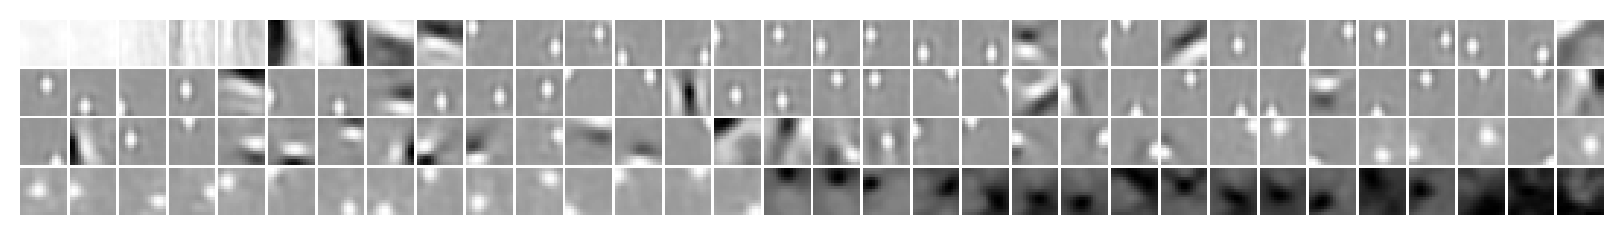

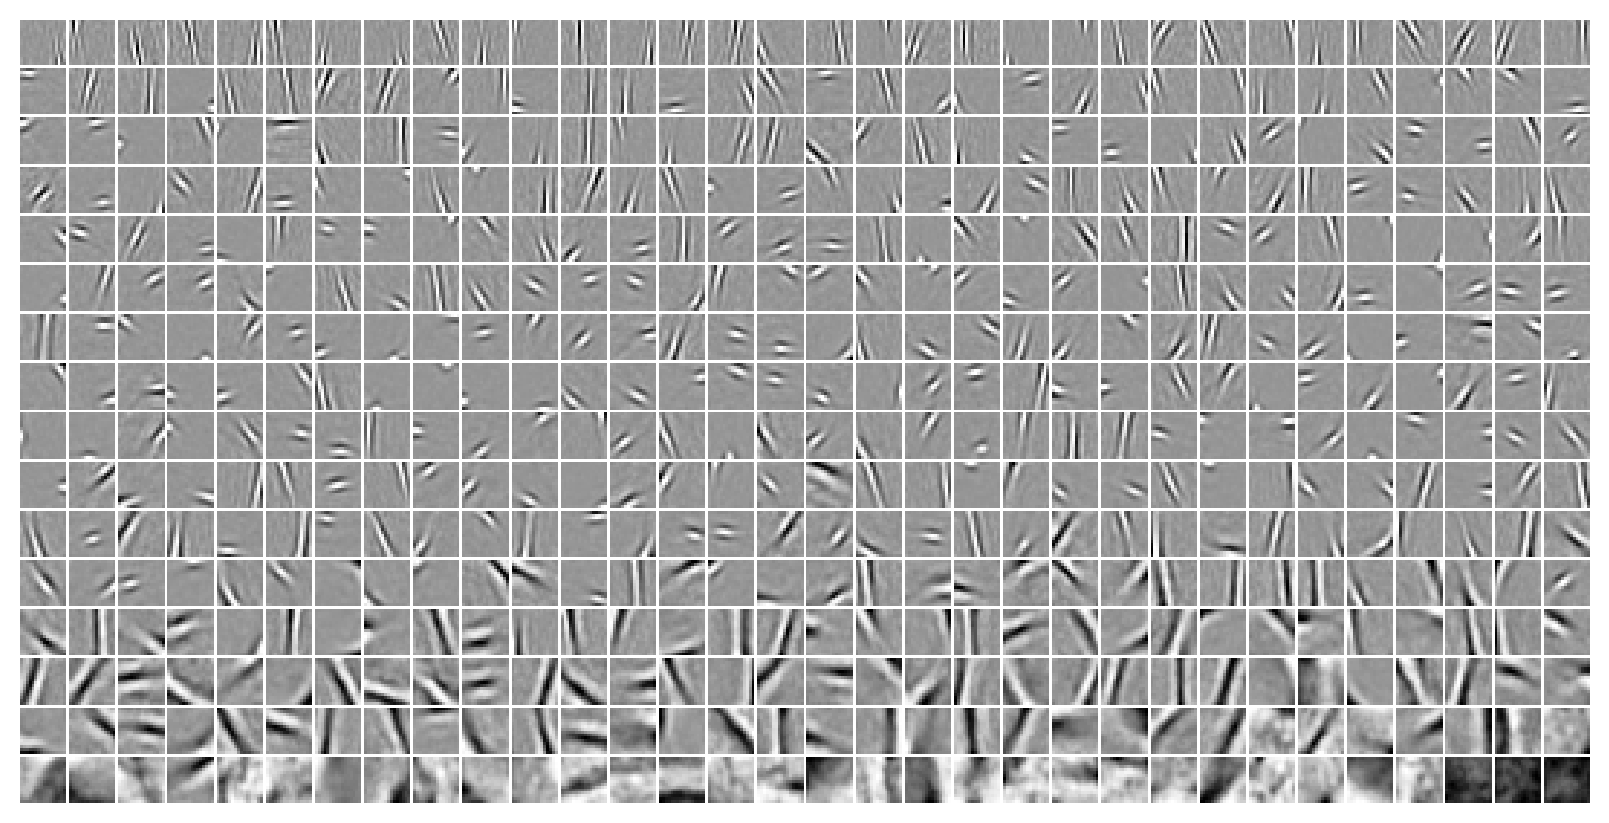

In [8]:
u0 = {
    k: tonp(layer.u_init[0].squeeze()) for
    k, layer in tr.model.layers.items()
}
for i, (k, v) in enumerate(u0.items()):
    kws = dict(
        order=np.argsort(v),
        nrows=tr.model.cfg.n_latents[i] // 32,
        method='abs-max',
    )
    tr.model.show(k, **kws);

## Fit (gompertz)

In [3]:
cfg_layers = {
    'g0': CFG_CLASSES['gaus'](n_latents=192, beta_outer=32.0, latent_act='gompertz'),
    'p1': CFG_CLASSES['pois'](n_latents=512, beta_outer=12.0),
}
cfg = Config(
    dataset='vH16-bw',
    cfg_layers=cfg_layers,
    t_train=16,
    n_iters_warmup=20,
)

In [4]:
tr = Trainer(
    model=RetinaV1(cfg),
    cfg=ConfigTrain(epochs=400),
    device=device,
)
tr.n_iters

206000

In [5]:
tr.print()

g0+gomp,p1_vH16-bw_t-[20+16]_b-[32,12]_k-[192,512]
b200-ep400-lr(0.002)_temp(0.01:0.5)_gr(500)_(2025_04_14,23:14)

In [6]:
tr.train()

epoch # 400, avg loss: -14.401: 100%|█████| 400/400 [12:10:54<00:00, 109.64s/it]


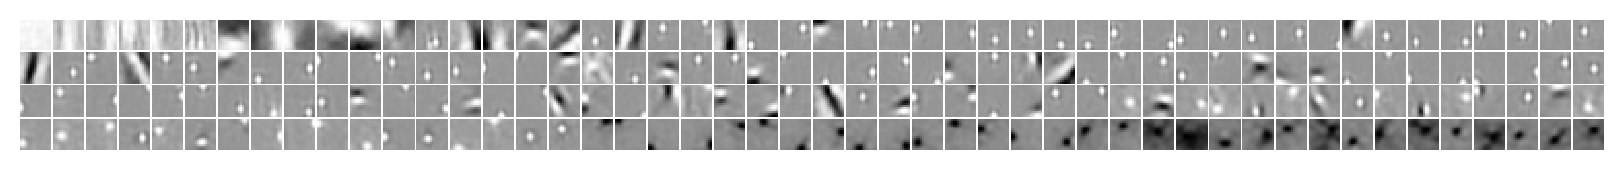

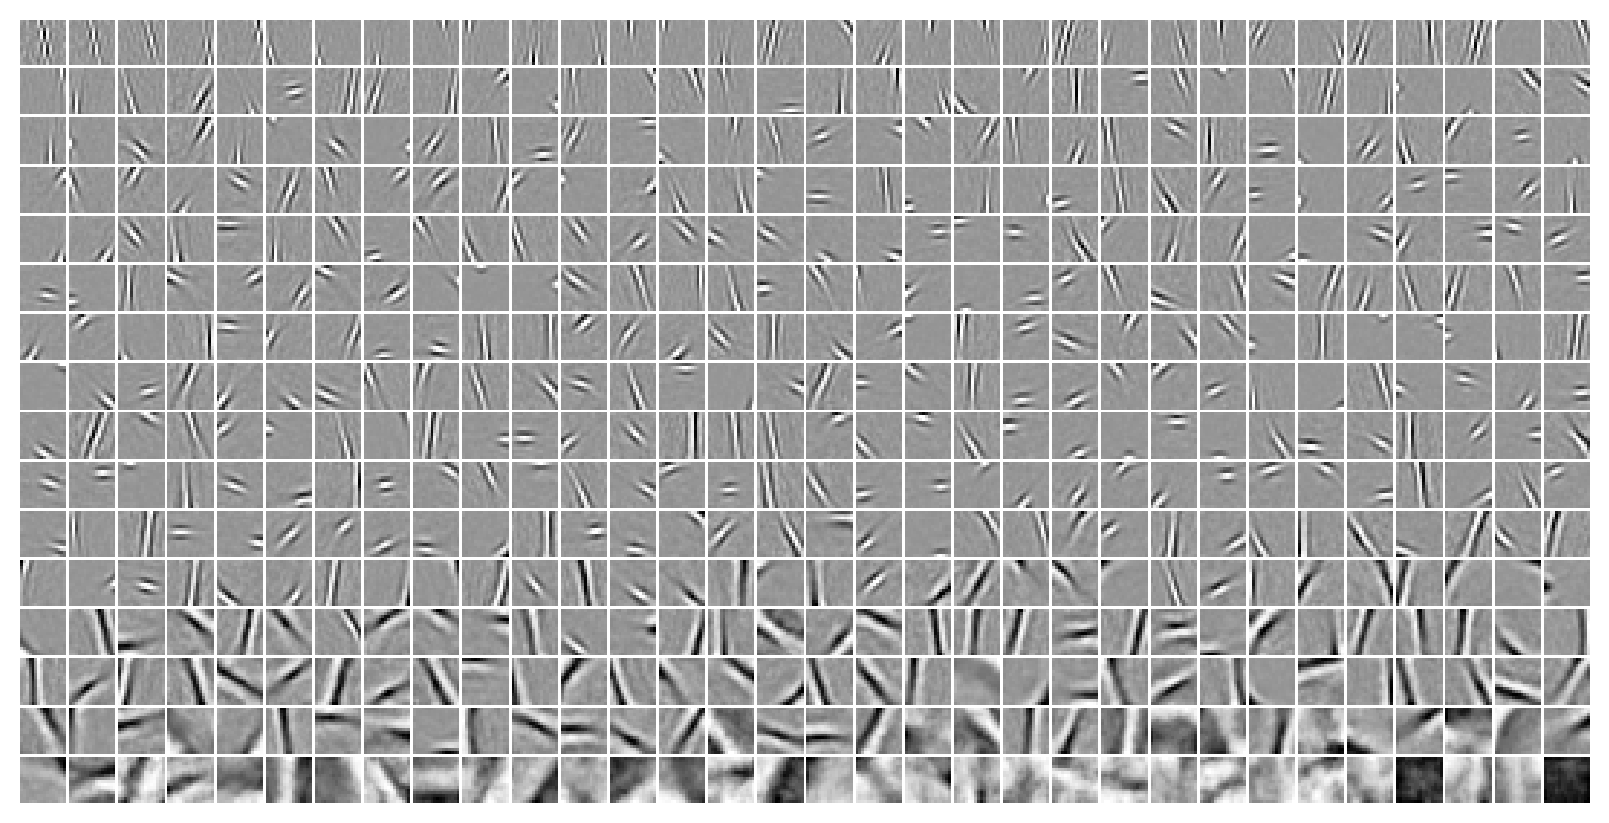

In [9]:
u0 = {
    k: tonp(layer.u_init[0].squeeze()) for
    k, layer in tr.model.layers.items()
}
for k, v in u0.items():
    kws = dict(
        order=np.argsort(v),
        nrows=16 if k == 'p1' else 4,
        method='abs-max',
    )
    tr.model.show(k, **kws);

In [10]:
var = {}
for name, layer in tr.model.layers.items():
    log_sigma = layer.get_dec_log_sigma()
    var[name] = tonp(torch.exp(log_sigma ** 2).squeeze()).reshape(16, 16)

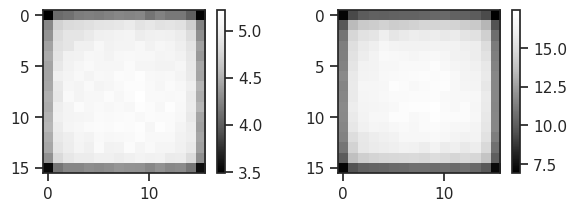

In [12]:
fig, axes = create_figure(1, 2)
im = axes[0].imshow(var['g0'], cmap='Greys_r')
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(var['p1'], cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

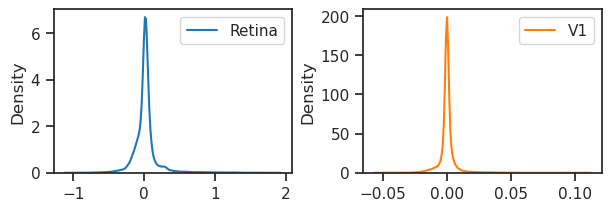

In [13]:
fig, axes = create_figure(1, 2)

sns.kdeplot(tonp(tr.model.layers['g0'].get_weight().ravel()), color='C0', label='Retina', ax=axes[0])
sns.kdeplot(tonp(tr.model.layers['p1'].get_weight().ravel()), color='C1', label='V1', ax=axes[1])

add_legend(axes)
plt.show()

In [14]:
tr.cfg.batch_size = 3000
tr.setup_data()

In [24]:
%%time


items = ['mse', 'r2', 'u', 'samples']

t_total = 1000

r2 = {k: np_nans(t_total) for k in tr.model.layers}
mse = {k: np_nans(t_total) for k in tr.model.layers}

true = []
pred = collections.defaultdict(list)
error = collections.defaultdict(list)

state = collections.defaultdict(list)
samples = collections.defaultdict(list)

for x, *_ in tqdm(iter(tr.dl_vld)):
    feeder = tr.get_feeder(x)
    for t in range(t_total):
        tr.model.update_time(t)
        inpt = feeder[t]
        output = tr.model.xtract_ftr(inpt, return_extras=items)
        for k, d in output.items():
            r2[k][t] = d['r2'].mean(0).item()
            mse[k][t] = d['mse'].mean(0).item()

        if (t + 1) == t_total:
            true.append(inpt.flatten(start_dim=1))
            for k, layer in tr.model.layers.items():
                pred[k].append(layer.conditional.loc)
                state[k].append(output[k]['u'])
                samples[k].append(output[k]['samples'])
            pred_error_retina = tr.model.layers['g0'].pred_error(
                x=inpt, weighted=False)
            error['g0'].append(pred_error_retina)
            error['p1'].append(tr.model.layers['p1'].pred_error(
                x=pred_error_retina, weighted=False))

del output
torch.cuda.empty_cache()
import gc
gc.collect()

true = torch.cat(true)
pred = {k: torch.cat(v) for k, v in pred.items()}
error = {k: torch.cat(v) for k, v in error.items()}
state = {k: torch.cat(v) for k, v in state.items()}
samples = {k: torch.cat(v) for k, v in samples.items()}

100%|█████████████████████████████████████████████| 9/9 [00:39<00:00,  4.37s/it]


CPU times: user 1min 16s, sys: 7.51 s, total: 1min 23s
Wall time: 1min 24s


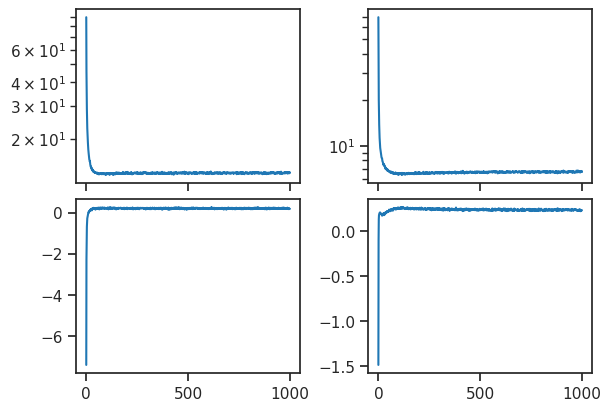

In [25]:
fig, axes = create_figure(2, 2, sharex='all')
axes[0, 0].plot(mse['g0'])
axes[0, 1].plot(mse['p1'])
axes[1, 0].plot(r2['g0'])
axes[1, 1].plot(r2['p1'])

axes[0, 0].set(yscale='log')
axes[0, 1].set(yscale='log')
# axes[-1, -1].set(xscale='log')
plt.show()

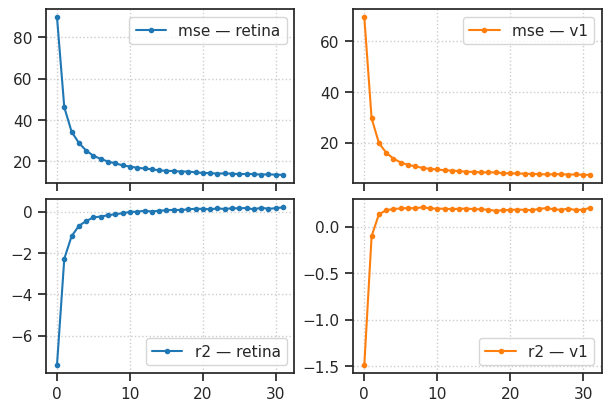

In [26]:
fig, axes = create_figure(2, 2, sharex='all')

intvl = range(32)

axes[0, 0].plot(mse['g0'][intvl], marker='.', label='mse — retina')
axes[0, 1].plot(mse['p1'][intvl], marker='.', color='C1', label='mse — v1')
axes[1, 0].plot(r2['g0'][intvl], marker='.', label='r2 — retina')
axes[1, 1].plot(r2['p1'][intvl], marker='.', color='C1', label='r2 — v1')

add_legend(axes)
add_grid(axes)
# axes[-1, -1].set(xscale='log')
plt.show()

In [27]:
r2['p1'][-10:]

array([0.23098254, 0.23810105, 0.22153841, 0.23328201, 0.22945054,
       0.2351785 , 0.23029007, 0.23151125, 0.23312815, 0.23119718])

In [28]:
# order: high contrast
var = tonp(torch.var(true, dim=1))
order = np.argsort(var)[::-1]

# get whitened data
_, whitened, _ = make_dataset('vH16-wht', device)
whitened = whitened.tensors[0].flatten(start_dim=1)
whitened.shape

torch.Size([25791, 256])

In [29]:
def _plot_selected_samples(select_from=None, ncols=20, seed=0):
    rng = get_rng(seed)

    nrows = 6
    fig, axes = create_figure(nrows, ncols, (1 * ncols + 0.1, 1 * nrows), 'all', 'all')

    select_from = order[:200] if select_from is None else select_from
    selected_ids = rng.choice(select_from, size=ncols, replace=False)

    for i in range(ncols):
        idx = selected_ids[i]
        axes[0, i].imshow(tonp(true[idx]).reshape(16, 16), cmap='Greys_r')
        axes[1, i].imshow(tonp(pred['g0'][idx]).reshape(16, 16), cmap='Greys_r')
        axes[2, i].imshow(tonp(error['g0'][idx]).reshape(16, 16), cmap='Greys_r')
        axes[3, i].imshow(tonp(whitened[idx]).reshape(16, 16), cmap='Greys_r')
        axes[4, i].imshow(tonp(pred['p1'][idx]).reshape(16, 16), cmap='Greys_r')
        axes[5, i].imshow(tonp(error['p1'][idx]).reshape(16, 16), cmap='Greys_r')
    
    axes[0, 0].set_ylabel('img', fontsize=15)
    axes[1, 0].set_ylabel('pred\n(retina)', fontsize=15)
    axes[2, 0].set_ylabel('error\n(retina)', fontsize=15)
    axes[3, 0].set_ylabel('whitened', fontsize=15)
    axes[4, 0].set_ylabel('pred\n(v1)', fontsize=15)
    axes[5, 0].set_ylabel('error\n(v1)', fontsize=15)

    remove_ticks(axes, False)
    plt.show()

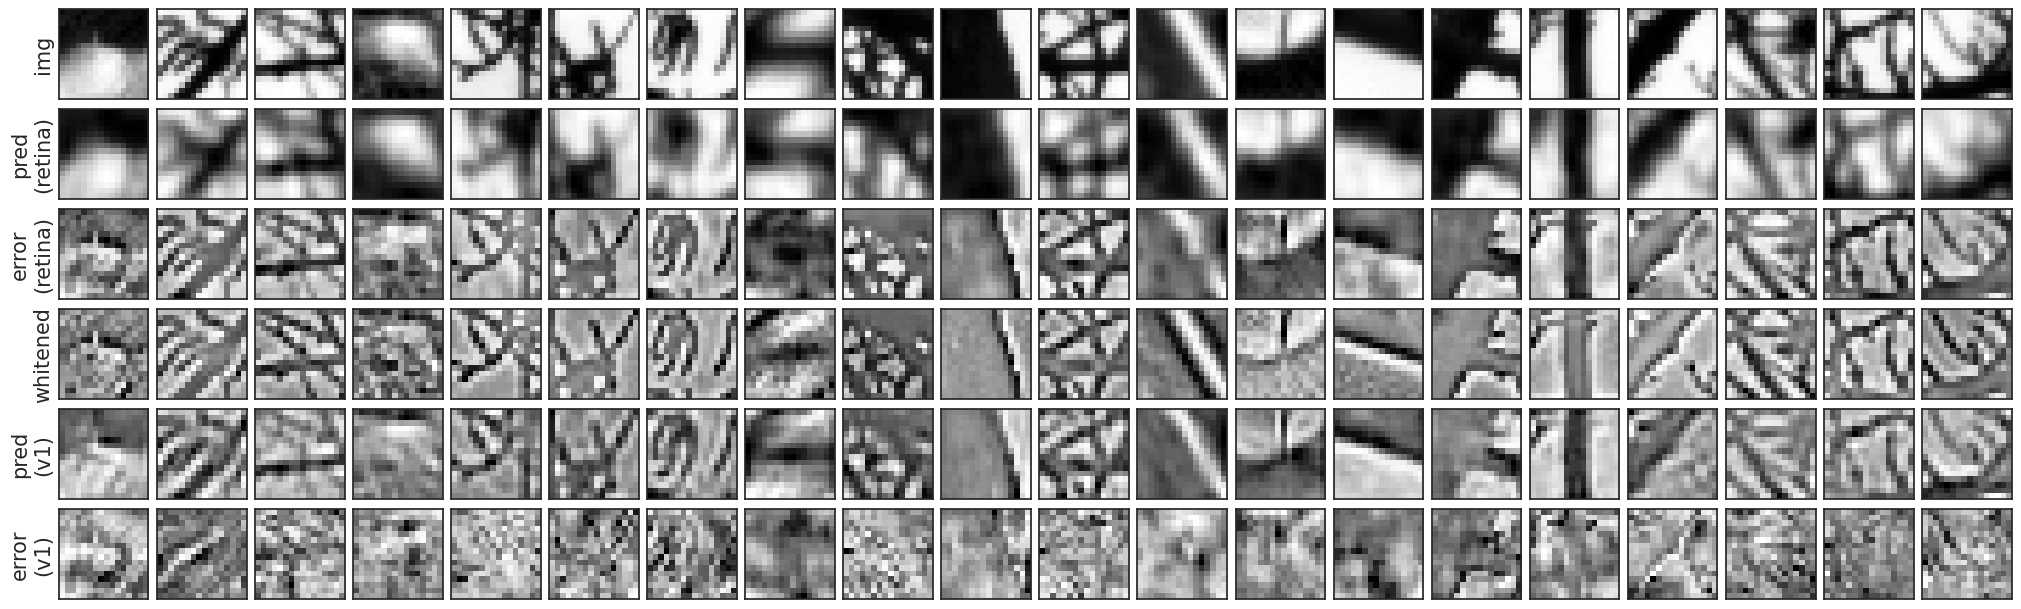

In [30]:
_plot_selected_samples()

In [32]:
error['g0'].shape

torch.Size([25791, 256])

In [31]:
phi_error = {
    k: tr.model.layers[k].phi(e, transpose=True)
    for k, e in error.items()
}

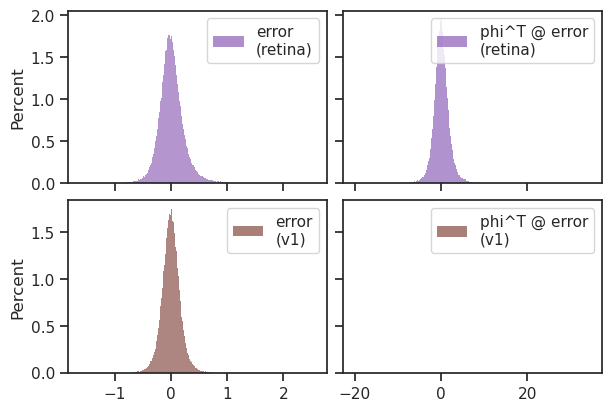

In [34]:
num = 1000

fig, axes = create_figure(2, 2, sharex='col', sharey='row')

sns.histplot(tonp(error['g0'][:num].ravel()), stat='percent', color='C4', label='error\n(retina)', ax=axes[0, 0])
sns.histplot(tonp(phi_error['g0'][:num].ravel()), stat='percent', color='C4', label='phi^T @ error\n(retina)', ax=axes[0, 1])
sns.histplot(tonp(error['p1'][:num].ravel()), stat='percent', color='C5', label='error\n(v1)', ax=axes[1, 0])
sns.histplot(tonp(phi_error['p1'][:num].ravel()), stat='percent', color='C5', label='phi^T @ error\n(v1)', ax=axes[1, 1])

add_legend(axes)
plt.show()

## White noise

In [3]:
a = 'g0+gomp,p1_vH16-bw_t-[20+16]_b-[32,12]_k-[192,512]'
b = 'b200-ep400-lr(0.002)_temp(0.01:0.5)_gr(500)_(2025_04_14,23:14)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

400

In [4]:
from analysis.sta import perform_sta_analysis
from utils.animation import show_movie

In [5]:
sta = perform_sta_analysis(tr, t_total=1, n_trials=100, batch_size=10_000)

100%|█████████████████████████████████████████| 100/100 [15:56<00:00,  9.56s/it]


In [6]:
n_lags = 80
s_kers = {
    name: np_nans((len(sta_array), 16, 16))
    for name, sta_array in sta.items()
}
t_kers = {
    name: np_nans((len(sta_array), n_lags + 1))
    for name, sta_array in sta.items()
}

for name, sta_array in sta.items():
    for i in range(len(sta_array)):
        uu, ss, vvh = torch.linalg.svd(
            sta_array[i], full_matrices=False)
    
        s_kers[name][i] = tonp(vvh[0]).reshape(16, 16)
        t_kers[name][i] = tonp(uu[:, 0])

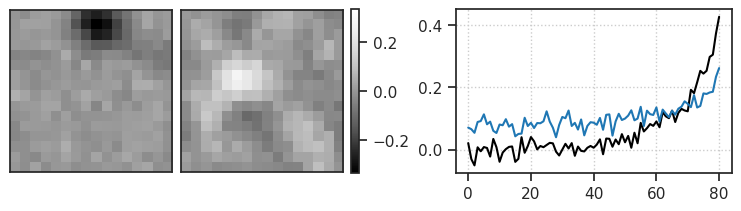

In [15]:
name = 'g0'
i, j = 44, 68
vminmax = np.abs(s_kers[name][[i, j]]).max()

fig, axes = create_figure(1, 3, (7.3, 2.0), width_ratios=[1, 1, 1.7])

im = axes[0].imshow(s_kers[name][i], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
im = axes[1].imshow(s_kers[name][j], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[1])

axes[2].plot(t_kers[name][i], color='k')
axes[2].plot(t_kers[name][j], color='C0')
axes[2].grid()

remove_ticks(axes[:2], False)
plt.show()

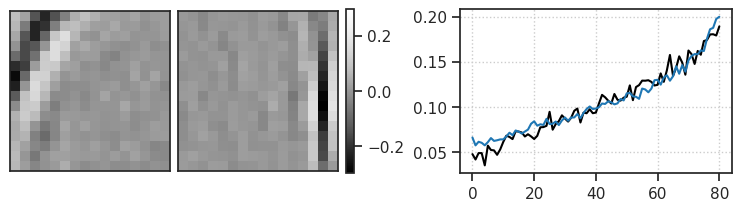

In [8]:
name = 'p1'
i, j = 57, 25
vminmax = np.abs(s_kers[name][[i, j]]).max()

fig, axes = create_figure(1, 3, (7.3, 2.0), width_ratios=[1, 1, 1.7])

im = axes[0].imshow(s_kers[name][i], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
im = axes[1].imshow(s_kers[name][j], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[1])

axes[2].plot(t_kers[name][i], color='k')
axes[2].plot(t_kers[name][j], color='C0')
axes[2].grid()

remove_ticks(axes[:2], False)
plt.show()

In [9]:
order = np.argsort(t_kers['g0'][:, 70])

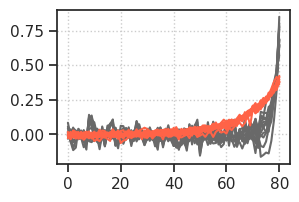

In [10]:
plot(t_kers['g0'][order][:13].T, color='dimgrey');
plot(t_kers['g0'][order][-13:].T, color='tomato');
plt.grid();

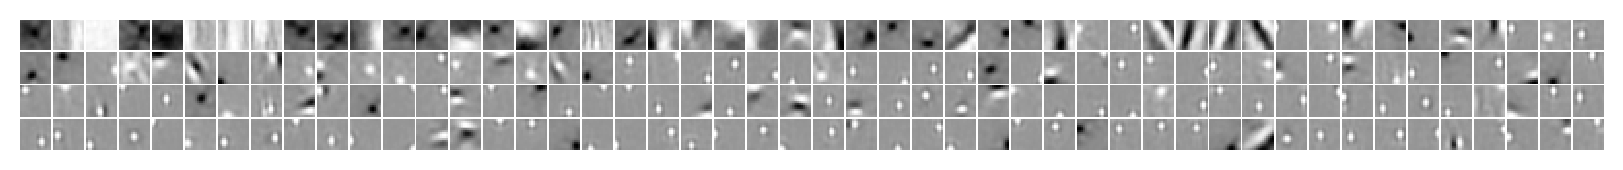

In [16]:
tr.model.show('g0', order=order, nrows=4, method='abs-max');